<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
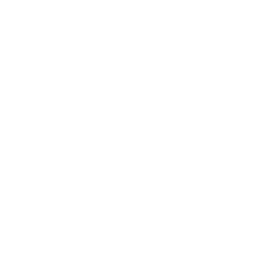
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Sales Representative Detailing Effectiveness with Lag Selection</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Commercial Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Evaluate the impact of physician detailing visits and sample distribution on monthly prescription volume for a specialty drug using PROC AUTOREG. Account for autocorrelated prescription patterns with NLAG=3 and apply the BACKSTEP option to drop insignificant lag orders automatically. Quantify the marginal return on each additional detailing visit to inform field force deployment decisions and territory alignment.

The synthetic monthly series spans 500 territory-months, which recovers the detailing, sampling, formulary, and competitor effects with high precision: every coefficient is estimated with a t value above 17 in absolute terms.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.DETAILING | Monthly prescriptions with detailing and sample metrics | 500 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic monthly detailing and Rx data
   for a specialty pharmaceutical product
   -------------------------------------------------------- */
data work.detailing;
    call streaminit(42);
    retain prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    do month_seq = 1 to 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* territory assignment rotates across 12 reps */
        rep_id = cat('REP-', put(mod(month_seq - 1, 12) + 1, z3.));
        /* detailing visits per month */
        detail_visits = int(rand('normal', 8, 3));
        if detail_visits < 0 then detail_visits = 0;
        if detail_visits > 20 then detail_visits = 20;
        /* sample units left with physicians */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* managed care formulary status (binary) */
        formulary_status = (rand('uniform') > 0.2);
        /* competitor share pressure */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* seasonal index */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3) error process */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* prescription model */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        if new_rx < 0 then new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        output;
    end;
    drop prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    format obs_month monyy7.;
run;

NOTE: DATA work.detailing


NOTE: Wrote work.detailing (500 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.80 seconds
  cpu   0.80 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline descriptive statistics for Rx and detailing
   -------------------------------------------------------- */
proc means data=work.detailing n mean std min max;
    var new_rx total_rx detail_visits samples_left competitor_share;
run;

                                                  The MEANS Procedure

 Variable                 N            Mean        Std Dev        Minimum         Maximum
 ----------------------------------------------------------------------------------------
 new_rx                 500     127.8700000     27.8161928     55.0000000     214.0000000
 total_rx               500     206.0960000     35.2443344     99.0000000     326.0000000
 detail_visits          500       7.5520000      3.0499016      0.0000000      17.0000000
 samples_left           500      30.4660000     16.1769042      0.0000000      90.0000000
 competitor_share       500       0.2942800      0.1326970      0.0300000       0.7000000
 ----------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


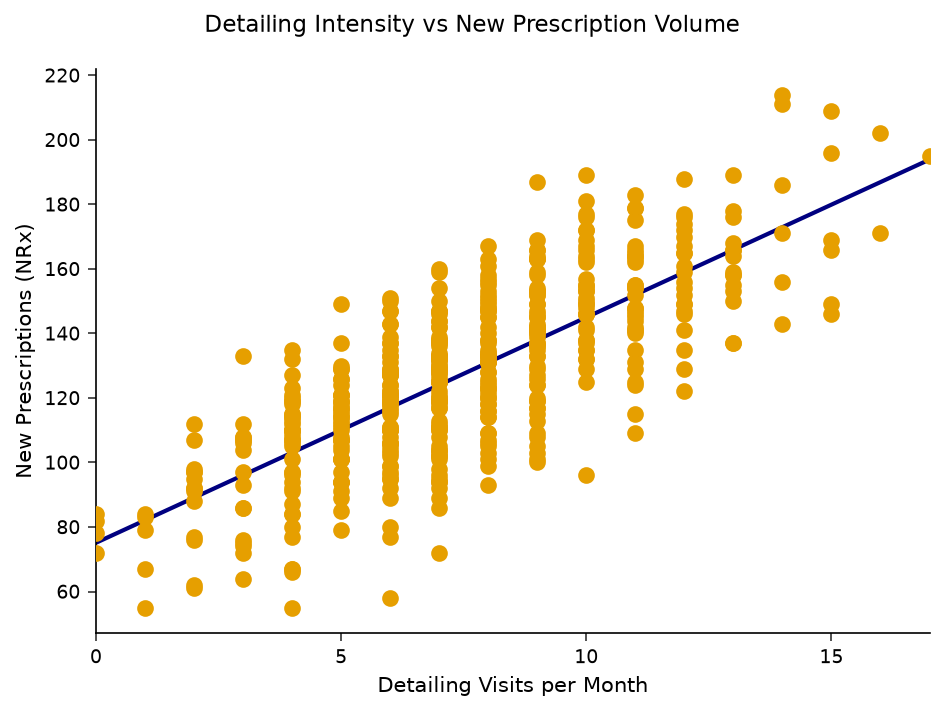

In [3]:
/* --------------------------------------------------------
   Scatter of detailing visits vs new prescriptions
   -------------------------------------------------------- */
proc sgplot data=work.detailing;
    scatter x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        markerattrs=(symbol=circlefilled size=7);
    reg x=detail_visits y=new_rx / lineattrs=(color=navy thickness=2);
    xaxis label='Detailing Visits per Month';
    yaxis label='New Prescriptions (NRx)';
    title 'Detailing Intensity vs New Prescription Volume';
run;

---

In [4]:
/* --------------------------------------------------------
   Fit autoregressive model with BACKSTEP lag selection
   NLAG=3 tests up to three lags; BACKSTEP removes
   insignificant lags automatically
   -------------------------------------------------------- */
proc autoreg data=work.detailing;
    model new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / nlag=3 backstep dwprob;
    output out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
run;


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       68.883915   1.484166     46.41    0.0000

          DETAIL_VISITS    3.418463   0.155489     21.99    0.0000

          SAMPLES_LEFT     0.833991   0.029103     28.66    0.0000

          FORMULARY_STATUS  25.524534   0.795749     32.08    0.0000

          COMPETITOR_SHARE -42.512734   2.425476    -17.53    0.0000



                        GARCH Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------



NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Capture parameter estimates for ROI calculation
   -------------------------------------------------------- */
ods output parameterestimates=work.detail_params;

proc autoreg data=work.detailing;
    model new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / nlag=3 backstep;
run;

ods output close;


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       68.883915   1.484166     46.41    0.0000

          DETAIL_VISITS    3.418463   0.155489     21.99    0.0000

          SAMPLES_LEFT     0.833991   0.029103     28.66    0.0000

          FORMULARY_STATUS  25.524534   0.795749     32.08    0.0000

          COMPETITOR_SHARE -42.512734   2.425476    -17.53    0.0000



                        GARCH Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------



NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Calculate marginal ROI per detailing visit
   The ODS ParameterEstimates dataset stores the Variable
   column in uppercase, so filter on 'DETAIL_VISITS'.
   -------------------------------------------------------- */
proc print data=work.detail_params;
    where variable = 'DETAIL_VISITS';
    title 'Marginal Effect of Detailing Visits on NRx';
run;

                                       Marginal Effect of Detailing Visits on NRx                                       

  Obs       VARIABLE     ESTIMATE     STD_ERROR        T_VALUE  PR_>__T_
    1  DETAIL_VISITS  3.418462737  0.1554889539  21.9852449469         0



NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interpretation

PROC AUTOREG fit the prescription series on 500 monthly territory observations. Each additional detailing visit is associated with **+3.42 new prescriptions per month** (estimate 3.4185, t = 21.99, p < 0.0001), and each unit of samples left with physicians adds **+0.83 NRx** (estimate 0.8340, t = 28.66), indicating that sampling reinforces but does not substitute for face-to-face promotion. Formulary access contributes **+25.52 NRx per month** (t = 32.08), underscoring managed care access as a precondition for detailing effectiveness, while competitor share exerts a strong negative effect of **-42.51 NRx per unit of share** (t = -17.53), flagging territories under competitive pressure where detailing alone may be insufficient. The intercept is 68.88.

With NLAG=3 and BACKSTEP, the model retained **two autoregressive lags**: lag 1 (coefficient -0.3749, t = -8.58) and lag 2 (coefficient -0.2131, t = -4.88); lag 3 was dropped as insignificant. The post-correction Durbin-Watson statistic is **1.04**, which still sits well below 2 and signals residual positive autocorrelation, so the AR(2) structure captures part but not all of the serial dependence in this series. Fit statistics: SSE = 30839.996, MSE = 62.303, AIC = 3496.27, SBC = 3529.99, log likelihood = -1740.13.

Field force planning should target territories with favorable formulary access and moderate competitor share, where the marginal return on each detailing visit is highest.

---

In [7]:
/* --------------------------------------------------------
   Export fitted values and parameters for field force
   planning dashboard
   -------------------------------------------------------- */
proc export data=work.detail_fitted
    outfile='detailing_effectiveness.csv'
    dbms=csv replace;
run;

proc export data=work.detail_params
    outfile='detailing_model_params.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 500 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>